## Outlier Analysis(Most Imp)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
print(np.arange(12))

[ 0  1  2  3  4  5  6  7  8  9 10 11]


In [4]:
data={
    "Name":['A','B','C','D','E','F','G','H','I','J'],
    "Marks":[85,72,90,80,88,91,95,87,300,5],
    "Age":[21,19,23,20,22,21,24,23,20,18],
    "City":["ahemdabad","delhi","delhi","mumbai","ahemdabad","Rajkot","Jamnagar","Limdi",'Surat',"Vadodra"]
}
df=pd.DataFrame(data);
df

,Name,Marks,Age,City
0,A,85,21,ahemdabad
1,B,72,19,delhi
2,C,90,23,delhi
3,D,80,20,mumbai
4,E,88,22,ahemdabad
5,F,91,21,Rajkot
6,G,95,24,Jamnagar
7,H,87,23,Limdi
8,I,300,20,Surat
9,J,5,18,Vadodra


In [5]:
df.loc[8]

Name         I
Marks      300
Age         20
City     Surat
Name: 8, dtype: object

### FILTERING
#### marks>80

In [6]:
df['Marks']>80

0     True
1    False
2     True
3    False
4     True
5     True
6     True
7     True
8     True
9    False
Name: Marks, dtype: bool

In [7]:
df[df['Marks']>80]

,Name,Marks,Age,City
0,A,85,21,ahemdabad
2,C,90,23,delhi
4,E,88,22,ahemdabad
5,F,91,21,Rajkot
6,G,95,24,Jamnagar
7,H,87,23,Limdi
8,I,300,20,Surat


In [8]:
df["City"]

0    ahemdabad
1        delhi
2        delhi
3       mumbai
4    ahemdabad
5       Rajkot
6     Jamnagar
7        Limdi
8        Surat
9      Vadodra
Name: City, dtype: object

In [9]:
df[df["City"]]

KeyError: "None of [Index(['ahemdabad', 'delhi', 'delhi', 'mumbai', 'ahemdabad', 'Rajkot',\n       'Jamnagar', 'Limdi', 'Surat', 'Vadodra'],\n      dtype='object')] are in the [columns]"

### `==` operator

In [10]:
df[df["City"]=="delhi"]

,Name,Marks,Age,City
1,B,72,19,delhi
2,C,90,23,delhi


### `&` Operator
- Students with age>21 and Marks>85

In [11]:
df["Age"]>21 & df["Marks"]>85 ## whenever you are chaining conditions pandas require you to enclose them in ()

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [12]:
(df["Age"]>21) & (df["Marks"]>85)

0    False
1    False
2     True
3    False
4     True
5    False
6     True
7     True
8    False
9    False
dtype: bool

In [13]:
df[(df["Age"]>21) & (df["Marks"]>85)]

,Name,Marks,Age,City
2,C,90,23,delhi
4,E,88,22,ahemdabad
6,G,95,24,Jamnagar
7,H,87,23,Limdi


### `|` Operator(Or Operator)
- Students from delhi or mumbai

In [16]:
(df["City"]=="delhi") | (df["City"]=="mumbai")

0    False
1     True
2     True
3     True
4    False
5    False
6    False
7    False
8    False
9    False
Name: City, dtype: bool

In [17]:
df[(df["City"]=="delhi") | (df["City"]=="mumbai")]

,Name,Marks,Age,City
1,B,72,19,delhi
2,C,90,23,delhi
3,D,80,20,mumbai


## Box Plot to visualize the Outlier

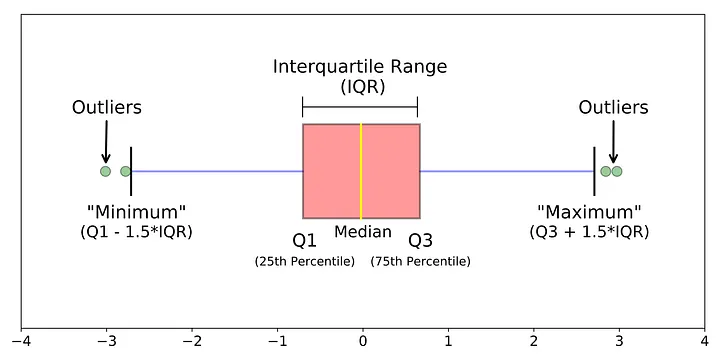

- Boxplot is an effective statistical tool to visualize the outliers and other metrics

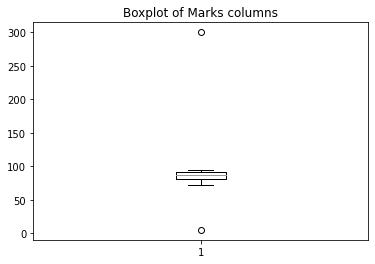

In [20]:
plt.boxplot(df["Marks"])
plt.title("Boxplot of Marks columns")
plt.show() ##Outliers squezzed the 

### Functions to detect the outliers

In [22]:
def detectoutlier(df,column):
    q1=df[column].quantile(0.25);
    q3=df[column].quantile(0.75);
    iqr=q3-q1;
    lower=q1-1.5*iqr;
    upper=q3+1.5*iqr;
    
    outliers=df[(df[column]<lower) | (df[column]>upper)]
    
    return outliers

In [23]:
detectoutlier(df,"Marks")

,Name,Marks,Age,City
8,I,300,20,Surat
9,J,5,18,Vadodra


### Function to remove outliers

In [28]:
def removeoutlier(df,column):
    q1=df[column].quantile(0.25);
    q3=df[column].quantile(0.75);
    iqr=q3-q1;
    lower=q1-1.5*iqr;
    upper=q3+1.5*iqr;
    
    cleandf=df[(df[column]>=lower) & (df[column]<=upper)]
    
    return cleandf

In [29]:
removeoutlier(df,"Marks")

,Name,Marks,Age,City
0,A,85,21,ahemdabad
1,B,72,19,delhi
2,C,90,23,delhi
3,D,80,20,mumbai
4,E,88,22,ahemdabad
5,F,91,21,Rajkot
6,G,95,24,Jamnagar
7,H,87,23,Limdi


In [30]:
df1=removeoutlier(df,"Marks")

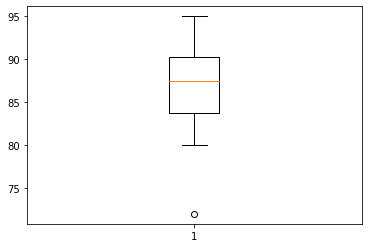

In [31]:
plt.boxplot(df1['Marks'])
plt.show()

In [32]:
def removeoutlier(df,column):
    q1=df[column].quantile(0.25);
    q3=df[column].quantile(0.75);
    iqr=q3-q1;
    lower=q1-1.5*iqr;
    upper=q3+1.5*iqr;
    
    cleandf=df[(df[column]>=lower) & (df[column]<=upper)]
    
    return cleandf

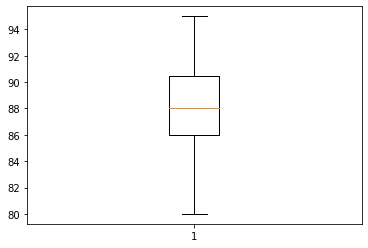

In [33]:
df2=removeoutlier(df1,"Marks")
plt.boxplot(df2['Marks'])
plt.show()